In [1]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import cmasher as cmr
import pandas as pd
from astropy.table import Table, vstack
import scipy
import pickle

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline
plt.rc('text', usetex=True)

import sys
import importlib
sys.path.append('../code/')
import helper

In [2]:
def save_coefs(directory, channel_file, n_channels, j_bins=20, start_timestep=0, end_timestep=None):
    file = np.loadtxt(directory+channel_file)
    n_times = file.shape[0]
    if end_timestep==None:
        times = np.reshape(file[start_timestep:,0], (n_times-start_timestep,1))
    else:
        times = np.reshape(file[start_timestep:end_timestep,0], (end_timestep-start_timestep,1))
    
    m0_amp_coefs = file[start_timestep:end_timestep,1:n_channels+1]# - 16*5]
    m1_amp_coefs = file[start_timestep:end_timestep,n_channels+1:2*n_channels+1]# - 16*5]
    m2_amp_coefs = file[start_timestep:end_timestep,2*n_channels+1:3*n_channels+1]# - 16*5]
    m1_pitch_coefs = file[start_timestep:end_timestep,3*n_channels+1:4*n_channels+1]# - 16*5]
    m2_pitch_coefs = file[start_timestep:end_timestep,4*n_channels+1:5*n_channels+1]# - 16*5]
    
    m1_amp_rel_coefs = m1_amp_coefs/m0_amp_coefs
    m2_amp_rel_coefs = m2_amp_coefs/m0_amp_coefs
    
    m0_amp = np.concatenate([times, m0_amp_coefs], axis=1)
    m1_amp = np.concatenate([times, m1_amp_coefs], axis=1)
    m2_amp = np.concatenate([times, m2_amp_coefs], axis=1)
    m1_pitch = np.concatenate([times, m1_pitch_coefs], axis=1)
    m2_pitch = np.concatenate([times, m2_pitch_coefs], axis=1)
    
    m1_amp_rel = np.concatenate([times, m1_amp_rel_coefs], axis=1)
    m2_amp_rel = np.concatenate([times, m2_amp_rel_coefs], axis=1)
    
    fname_prefix = directory+'mssa_channels_kiyan_fast/'
    np.savetxt(fname_prefix + 'm0_amp_bins_j{}_t16.dat'.format(j_bins), m0_amp)
    np.savetxt(fname_prefix + 'm1_amp_bins_j{}_t16.dat'.format(j_bins), m1_amp)
    np.savetxt(fname_prefix + 'm2_amp_bins_j{}_t16.dat'.format(j_bins), m2_amp)
    np.savetxt(fname_prefix + 'm1_pitch_bins_j{}_t16.dat'.format(j_bins), m1_pitch)
    np.savetxt(fname_prefix + 'm2_pitch_bins_j{}_t16.dat'.format(j_bins), m2_pitch)
    np.savetxt(fname_prefix + 'm1_amp_rel_bins_j{}_t16.dat'.format(j_bins), m1_amp_rel)
    np.savetxt(fname_prefix + 'm2_amp_rel_bins_j{}_t16.dat'.format(j_bins), m2_amp_rel)

In [3]:
tbl = Table.read('../data/kiyan-fast_mssa_prep_table.fits')
tbl.sort(["timestep", "jphi_cen", "tphi_cen"])

In [4]:
np.unique(tbl['pitch_phase_flag_m1'], return_counts=True)

(<Column name='pitch_phase_flag_m1' dtype='float64' length=3>
 0.0
 1.0
 2.0,
 array([73088, 27446,   266]))

In [5]:
jphi_c = np.linspace(1000, 3000, 20+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
centers = np.array(np.meshgrid(jphi_c, tphi_c)).T.reshape(-1,2)

cfs_m0_amp    = ['m0_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_amp    = ['m1_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_amp    = ['m2_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_pitch  = ['m1_pitch_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_pitch  = ['m2_pitch_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_phase  = ['m1_phase_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_phase  = ['m2_phase_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]

colnames = ['timestep']+cfs_m0_amp+cfs_m1_amp+cfs_m2_amp+cfs_m1_pitch+cfs_m2_pitch+cfs_m1_phase+cfs_m2_phase

t = Table(names=colnames)

for time in np.unique(tbl['timestep']):
    subset = tbl[tbl['timestep'] == time]
    channels = np.concatenate([np.array(subset['m0_amp']), np.array(subset['m1_amp']), np.array(subset['m2_amp']),
                                    np.array(subset['pitch_ang_m1']), np.array(subset['pitch_ang_m2']), 
                                    np.array(subset['phase_ang_m1']), np.array(subset['phase_ang_m2'])])
    #amps = np.concatenate((subset['m1_amp'], subset['m2_amp']))
    t.add_row(np.append([time], channels))

# np.savetxt('../data/kiyan-fast_for_mssa.dat', t)

KeyboardInterrupt: 

In [ ]:
40*0.009778

In [ ]:
save_coefs(directory='../data/', channel_file='kiyan-fast_for_mssa.dat', 
           n_channels=336, j_bins=20, start_timestep=38, end_timestep=None)

### Loading in Files

In [6]:
directory = '../data/mssa_channels_kiyan_fast/'

fname_m0_amp = directory+'m0_amp_bins_j20_t16.dat'

fname_m1_amp = directory+'m1_amp_bins_j20_t16.dat'
fname_m1_pitch = directory+'m1_pitch_bins_j20_t16.dat'
fname_m1_rel_amp = directory+'m1_amp_rel_bins_j20_t16.dat'

fname_m2_amp = directory+'m2_amp_bins_j20_t16.dat'
fname_m2_pitch = directory+'m2_pitch_bins_j20_t16.dat'
fname_m2_rel_amp = directory+'m2_amp_rel_bins_j20_t16.dat'


coefs_m1_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m1_rel_amp)
coefs_m1_pitch0 = pyEXP.coefs.Coefs.factory(fname_m1_pitch)
coefs_m2_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m2_rel_amp)
coefs_m2_pitch0 = pyEXP.coefs.Coefs.factory(fname_m2_pitch)

coefs_m1_rel_amp = coefs_m1_rel_amp0.deepcopy()
coefs_m1_pitch = coefs_m1_pitch0.deepcopy()
coefs_m2_rel_amp = coefs_m2_rel_amp0.deepcopy()
coefs_m2_pitch = coefs_m2_pitch0.deepcopy()

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [7]:
# A list with three keys.  Keys are integer arrays (or lists).  
# The first column of the data table has the key [0], etc.
#keylst = [[i] for i in range(len(coefs.getAllCoefs()))]

n_channels = int(len(coefs_m1_pitch.getAllCoefs()))
times = coefs_m1_pitch.Times()

keylst_m1_amp = [[i] for i in range(n_channels)]
keylst_m1_pitch = [[i] for i in range(n_channels)]
keylst_m2_amp = [[i] for i in range(n_channels)]
keylst_m2_pitch = [[i] for i in range(n_channels)]

config = {"snails_m1_amp_rel": (coefs_m1_rel_amp, keylst_m1_amp, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

---- Eigen is using 4 threads


In [8]:
fig_dir = '../figures/kiyan_fast_figures/m1_amp/'

In [9]:
ev = mssa.eigenvalues()

shape U = 44016 x 132
shape Y = 132 x 44016


In [10]:
coefs_m1_rel_amp.zerodata()
mssa.reconstruct([*range(30)])

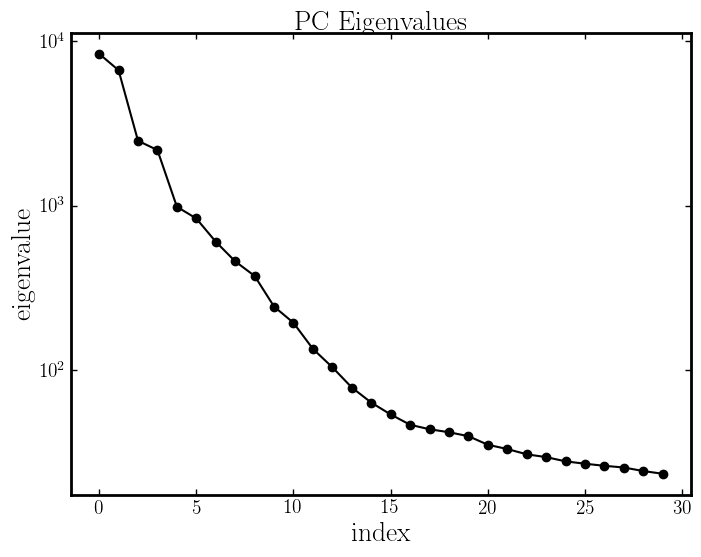

In [11]:
%matplotlib inline
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

ax1.semilogy(ev[:30], '-o')

ax1.set_xlabel('index', fontsize=20)
ax1.set_ylabel('eigenvalue', fontsize=20)
    
ax1.set_title('PC Eigenvalues', fontsize=20)
#plt.savefig(fig_dir+'eigenvalues.pdf')
#plt.savefig(fig_dir+'eigenvalues.png')
plt.show()

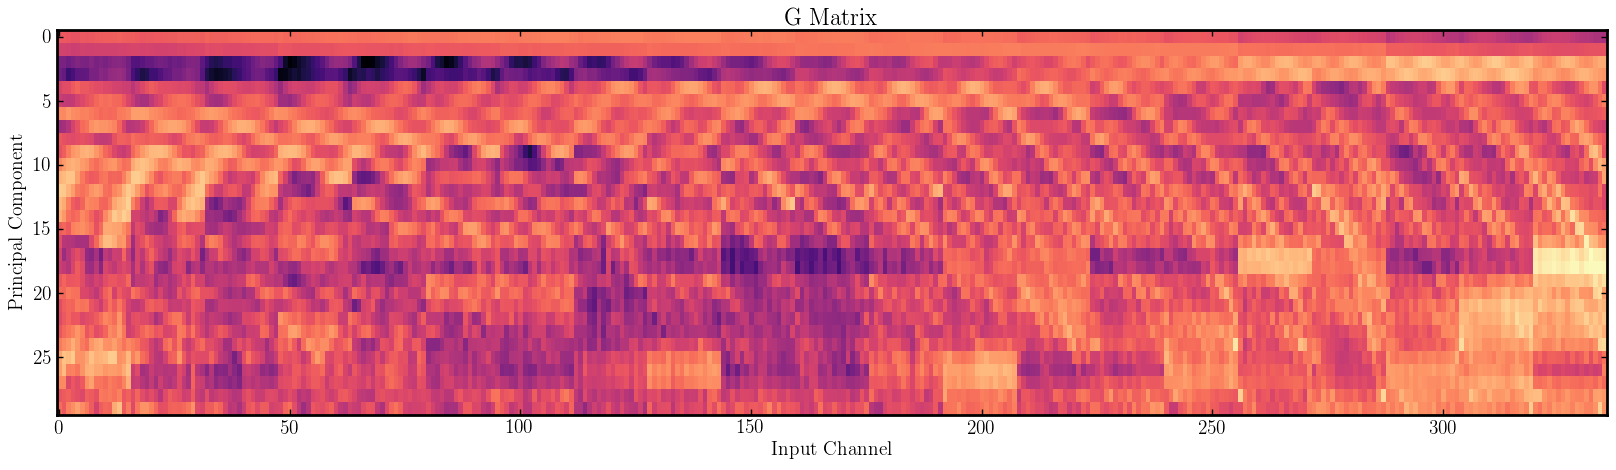

In [12]:
# t1 is each PCs contribution to each channel, t2 is each channels contribution to each PC
t1, t2 = mssa.contrib()
plt.figure(figsize=(20, 5))
plt.imshow(t2, aspect='auto', norm=mpl.colors.LogNorm())
plt.xlabel('Input Channel')
plt.ylabel('Principal Component')
plt.title('G Matrix')
plt.show()

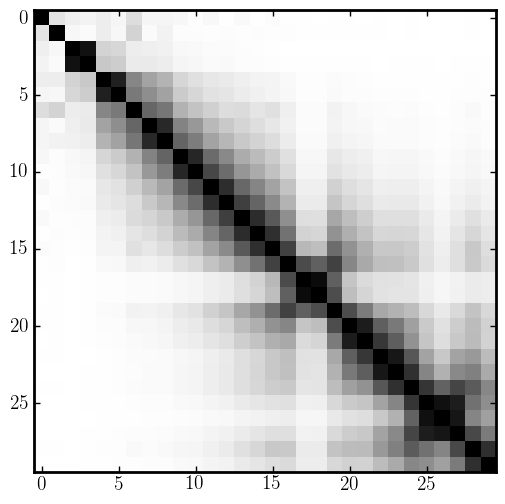

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6,6), sharey=True)

ax.imshow(mssa.wCorrAll()[:30, :30], cmap='gray_r')
#plt.savefig(fig_dir+'wCorr30.pdf')
#plt.savefig(fig_dir+'wCorr30.png') 
plt.show()

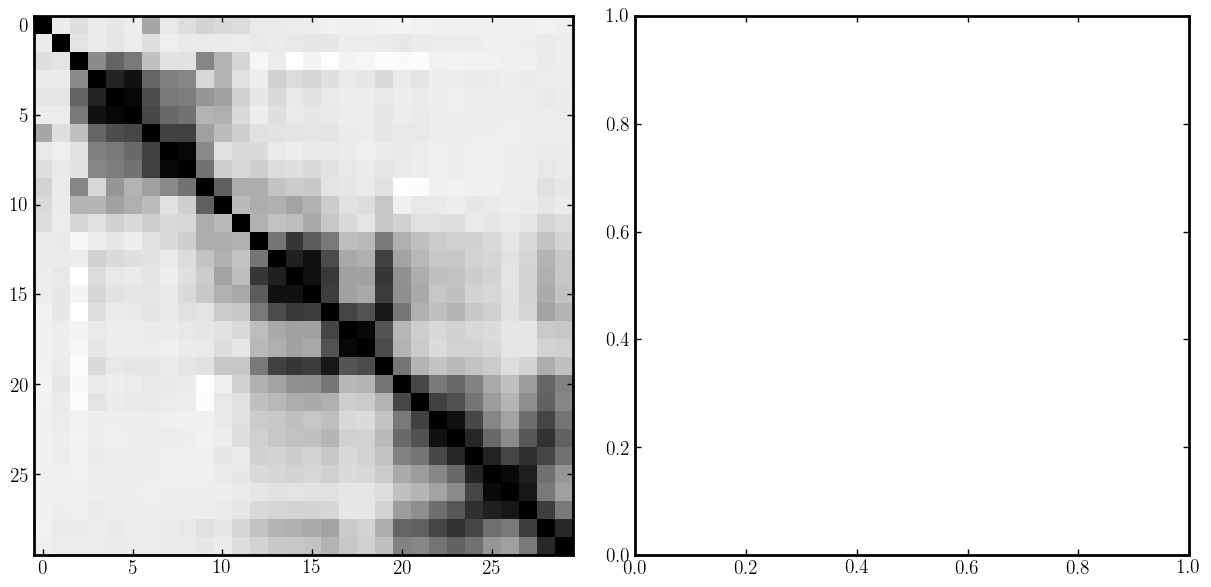

In [14]:
# wCorr for amplitude:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15,7))
ax1.imshow(mssa.wCorrKey([0]), cmap='gray_r')
#ax2.imshow(mssa.wCorrKey([1]), cmap='gray_r')
plt.show()

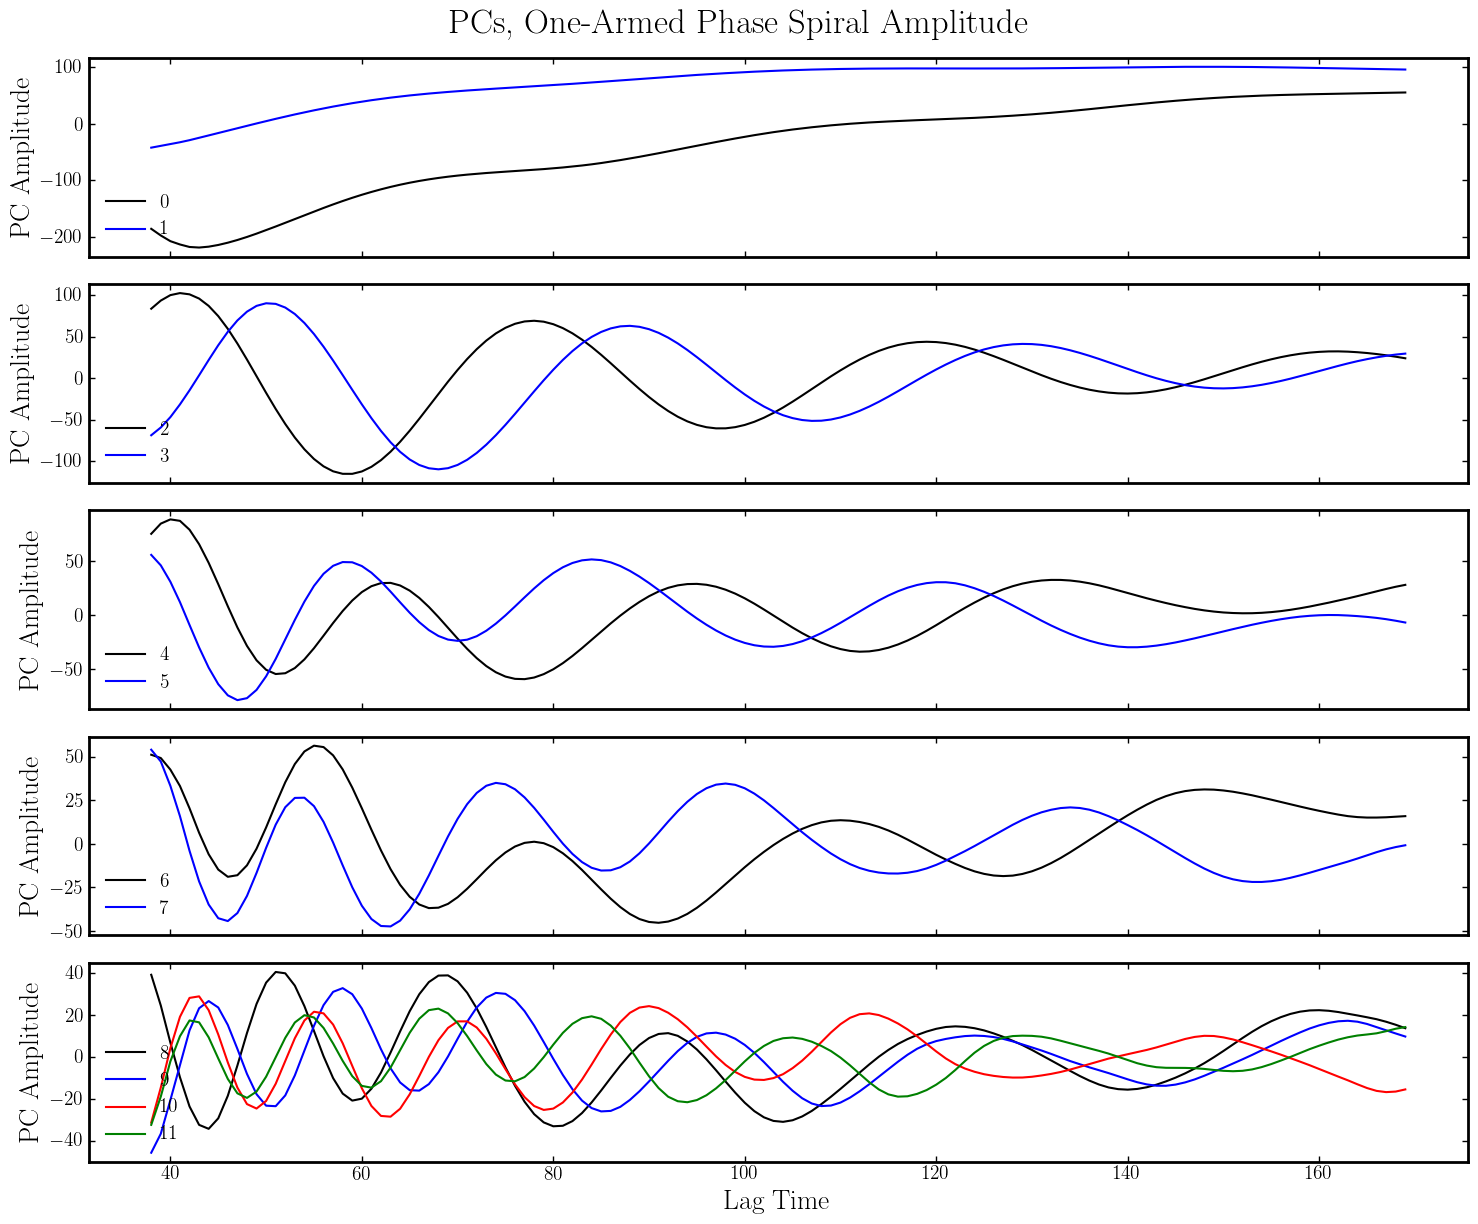

In [15]:
%matplotlib inline
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(15, 2.5*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

plt.suptitle('PCs, One-Armed Phase Spiral Amplitude', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

for i in range(n_plots):
    axs[i].set_ylabel('PC Amplitude', fontsize=20)
    axs[i].legend(fontsize=14, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
#plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

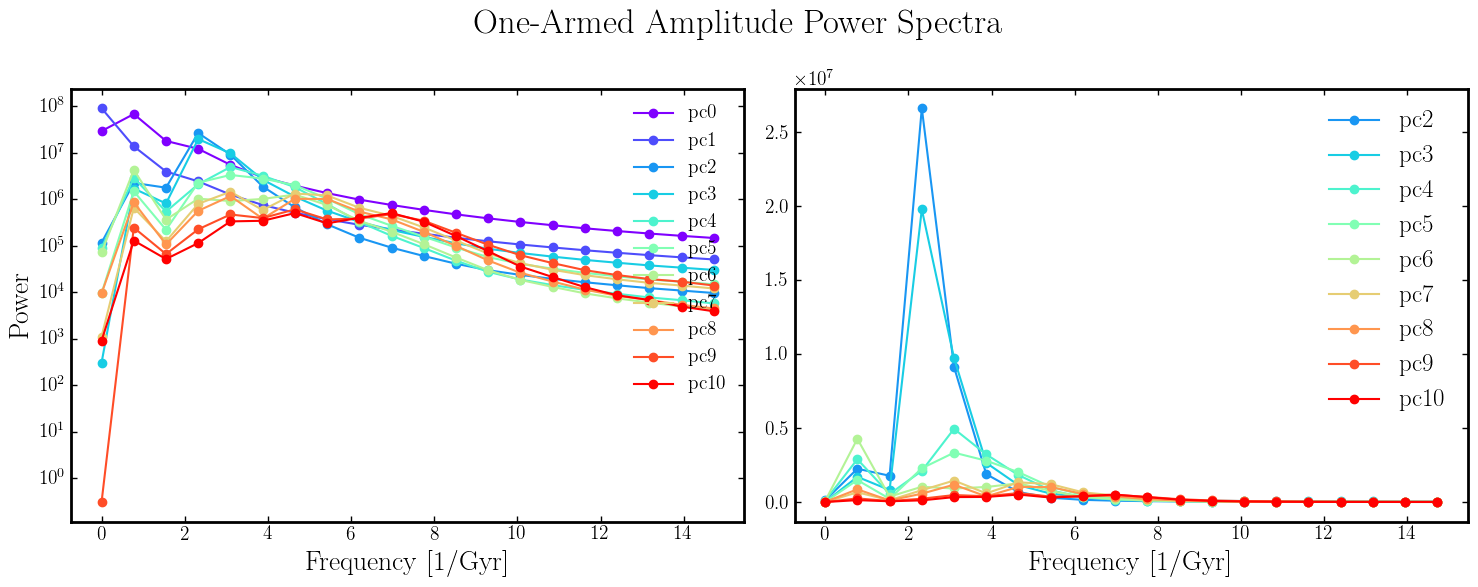

In [16]:
freq, power = mssa.pcDFT()
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15, 6))

color = iter(cm.rainbow(np.linspace(0, 1, 11)))
    
for i in range(0, 11,1):
    c = next(color)
    ax1.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

    if i>=2:
        ax2.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

ax1.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax2.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax1.legend(markerscale=1) ; ax2.legend(markerscale=1, fontsize=18)
ax1.set_ylabel('Power', fontsize=20)
ax1.set_yscale('log')

plt.suptitle('One-Armed Amplitude Power Spectra', fontsize=25)
fig.tight_layout()
#plt.savefig(fig_dir+'power_spectrum.pdf')
plt.show()

In [44]:
power[:20,2].shape

(20,)

In [47]:
np.linalg.norm(power[:20,:2], axis=1).shape

(20,)

#### Paper Plot

In [17]:
freqs = np.load('../data/test_frequency_array_j25.npy')[:21]
freqs

array([7.59670671, 6.97484319, 6.41869093, 5.92313979, 5.48071794,
       5.08427202, 4.73053109, 4.41235123, 4.12851134, 3.87241322,
       3.64171986, 3.43173484, 3.24276922, 3.07077143, 2.91375766,
       2.7700754 , 2.63923324, 2.51938706, 2.40718516, 2.30580754,
       2.21140019])

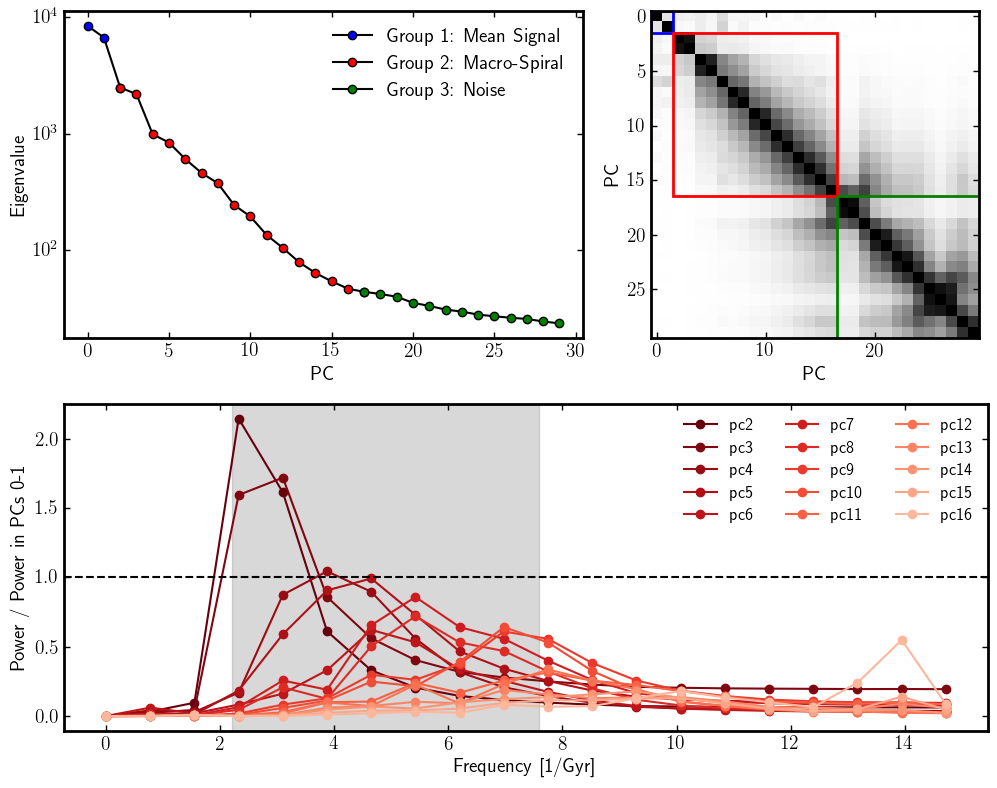

In [203]:
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

eigenvalues = ev[:30]
cov_matrix = mssa.wCorrAll()[:30, :30]

# Setting up the figure and gridspec
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 3, width_ratios=[3, 2, 0.1], height_ratios=[1, 1], hspace=0.2, wspace=0.2, left=0.06, right=1.06, bottom=0.07, top=0.97)

# Top left: Eigenvalue plot (3/5 of the width)
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(np.arange(0,3), eigenvalues[:3], 'o-', label='Group 1: Mean Signal', c='k', mfc='blue')
ax1.semilogy(np.arange(2,18), eigenvalues[2:18], 'o-', label='Group 2: Macro-Spiral', c='k', mfc='red')
ax1.semilogy(np.arange(17, 30), eigenvalues[17:], 'o-', label='Group 3: Noise', c='k', mfc='green')
ax1.set_xlabel('PC')
ax1.set_ylabel('Eigenvalue')
ax1.legend()

# Top right: Covariance Matrix (2/5 of the width)
ax2 = fig.add_subplot(gs[0, 1])
im = ax2.imshow(cov_matrix, cmap='gray_r')
ax2.set_xlabel('PC')
ax2.set_ylabel('PC')

# Highlighting groups in covariance plot
ax2.add_patch(Rectangle((-0.5, -0.5), 2, 2, fill=False, edgecolor='blue', lw=2))
ax2.add_patch(Rectangle((1.5, 1.5), 15, 15, fill=False, edgecolor='red', lw=2))
ax2.add_patch(Rectangle((16.5, 16.5), 15, 15, fill=False, edgecolor='green', lw=2))

# Bottom: Power spectrum plot
ax3 = fig.add_subplot(gs[1, :2])
color = iter(cm.Reds_r(np.linspace(0, 1, 20)))
for i in range(2, 17):
    c = next(color)
    ax3.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i]/np.linalg.norm(power[:20,:2], axis=1), 'o-', c=c, label=f'pc{i}')
ax3.axhline(1.0, color='black', linestyle='--')
ax3.set_xlabel('Frequency [1/Gyr]')
ax3.set_ylabel('Power / Power in PCs 0-1')
ax3.axvspan(freqs[-1], freqs[0], alpha=0.3, color='gray')
ax3.legend(ncol=3, fontsize='small')
plt.savefig(fig_dir+'mSSA_quick_plots.pdf')

### Face-on Plots

In [18]:
importlib.reload(sys.modules['helper'])
from helper import *

In [19]:
tbl_pitch = np.loadtxt(directory+'m1_pitch_bins_j20_t16.dat')
tbl_rel_amp = np.loadtxt(directory+'m1_amp_rel_bins_j20_t16.dat')

f = fig_dir+'face-on_plots/data.mp4'
f_sub = fig_dir+'face-on_plots/data_subtract_pc0-1.mp4'

# MakeAnim = MakeAnimations(mssa, 'amp', times, n_channels, [0,1], jbins=20)
# MakeAnim.make_pre_mssa_face_on(f, tbl_rel_amp, tbl_pitch)
# MakeAnim.make_pre_mssa_face_on_subtracted(f_sub, tbl_rel_amp, tbl_pitch)

Updating for: (c)_0
Updating for: (s)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (~)_0
Updating for: ([)_0
Updating for: (")_0
Updating for: (3)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


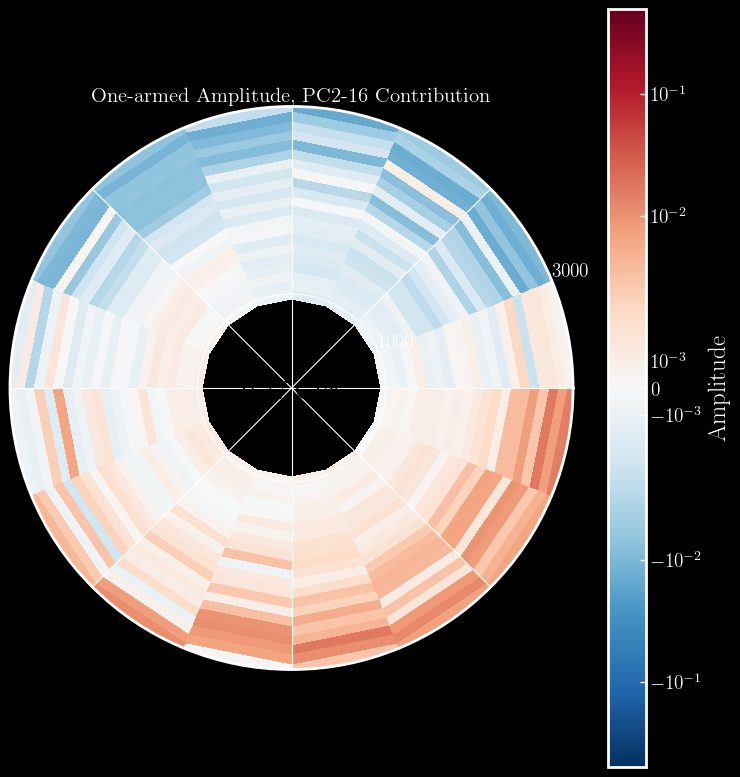

In [20]:
# f = fig_dir+'face-on_plots/pc0+pc1.mp4'
# MakeAnim0 = MakeAnimations(mssa, 'amp', times, n_channels, [0,1], jbins=20)
# MakeAnim0.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc2+pc3.mp4'
# MakeAnim1 = MakeAnimations(mssa, 'amp', times, n_channels, [2,3], jbins=20)
# MakeAnim1.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc2-5.mp4'
# MakeAnim2 = MakeAnimations(mssa, 'amp', times, n_channels, list(range(2,6)), jbins=20)
# MakeAnim2.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc2-6.mp4'
# MakeAnim3 = MakeAnimations(mssa, 'amp', times, n_channels, list(range(2,7)), jbins=20)
# MakeAnim3.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc2-8.mp4'
# MakeAnim4 = MakeAnimations(mssa, 'amp', times, n_channels, list(range(2,9)), jbins=20)
# MakeAnim4.make_recon_mov_disk_plot(f)

plt.style.use('dark_background')
f = fig_dir+'face-on_plots/pc2-16.mp4'
MakeAnim5 = MakeAnimations(mssa, 'amp', times, n_channels, list(range(2,17)), jbins=20)
MakeAnim5.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc4-5.mp4'
# MakeAnim6 = MakeAnimations(mssa, 'amp', times, n_channels, [4,5], jbins=20)
# MakeAnim6.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc4-16.mp4'
# MakeAnim7 = MakeAnimations(mssa, 'amp', times, n_channels, list(range(4,17)), jbins=20)
# MakeAnim7.make_recon_mov_disk_plot(f)

### Rewinding to a Dipole

In [21]:
# To get colorbar
jphi_c = np.linspace(1000, 3000, 20+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

In [22]:
# Take Reconstructions

mssa.reconstruct(list(range(2,17)))
get_recon = mssa.getReconstructed()

recon_amp_ = get_recon[list(get_recon.keys())[0]].getAllCoefs()
recon_amp = recon_amp_ - np.mean(recon_amp_, axis=0)

# what is omega_phi at each radius, in rad/Gyr?
omega_phi = freqs*2*np.pi

time_diff = times[1]-times[0]

ratio = 0.01

Updating for: (c)_0
Updating for: (s)_0
Updating for: (@)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: (c)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (`)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


In [23]:
def shearing_box_hack(timestep, reconstruction, omega_phi, coef_times, axs, rewind_time, jbins):
    
    ax1, ax2 = axs
    ax1.clear() ; ax2.clear()
    
    t = timestep
    
    rad_mean_amp = np.mean(np.reshape(reconstruction[:,t], (16,jbins+1), 'F'), axis=0)

    #plot what that timestep looks like after subtracting background
    
    # amplitude
    im1 = ax1.pcolormesh(T, J, reconstruction[:,t].reshape((jbins+1, 16)).T - rad_mean_amp, cmap='RdBu_r', 
               norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')
    # pitch angle
    # im1 = ax1.pcolormesh(T, J, reconstruction[:,t].reshape((21, 16)).T - rad_mean_amp, cmap='RdBu_r', 
    #            norm=mpl.colors.SymLogNorm(linthresh=0.1, vmax=1, vmin=-1), shading='nearest')
    

    # how far has each region traveled since the time of interaction?
    time_elapsed = (t + coef_times[0])*ratio - rewind_time
    d_rot = time_elapsed*omega_phi

    #now interpolate at each radius so that I can use the same grid as before
    interp = scipy.interpolate.interp1d(tphi_c, reconstruction[:,t].reshape((jbins+1, 16)), axis=1, 
                                        fill_value="extrapolate")
    all_interp = interp((T+d_rot)%(2*np.pi))
    past_grid = np.diagonal(all_interp, axis1=0, axis2=2)

    #plot what that timestep looks like after subtracting background
    #AMPLITUDE
    im2 = ax2.pcolormesh(T, J, past_grid - rad_mean_amp, cmap='RdBu_r', 
                    norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')
    #PITCH ANGLE
    # im2 = ax2.pcolormesh(T, J, past_grid - rad_mean_amp, cmap='RdBu_r', 
    #                 norm=mpl.colors.SymLogNorm(linthresh=0.1, vmax=1, vmin=-1), shading='nearest')
    #plt.colorbar(im2, ax=ax2)
    #ax2.plot([sgr_ang_at_impact+np.pi,sgr_ang_at_impact], [4000,4000], c='k', ls='dashed')
    
    
    
    ax1.text(3*np.pi/2, 100, r'{} Gyr'.format(np.around((coef_times[0]+t)*ratio, 2)), fontsize=20, 
            ha="center", c='k')
    ax2.text(3*np.pi/2, 100, r'{} Gyr'.format(np.around((coef_times[0]+t)*ratio, 2)), fontsize=20, 
            ha="center", c='k')
    
    ax1.set_title('One-armed Amplitude, PC2-16 Contribution', fontsize=25)
    ax2.set_title('Re-winding Approximation', fontsize=25)
    plt.draw()
    
def shearing_box_movie(reconstruction, omega_phi, coef_times, filename, jbins, rewind_time):
    fig, axs = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': 'polar'})
    
    #fig.tight_layout()
    
    anim = FuncAnimation(
        fig,
        partial(shearing_box_hack, reconstruction=reconstruction, omega_phi=omega_phi, 
                coef_times=coef_times, axs=axs, rewind_time=rewind_time, jbins=jbins),
        frames=np.arange(0, int(len(coef_times)), 1),
        interval=2,
        blit=False,
    )
    FFwriter = animation.FFMpegWriter(fps=10)
    anim.save(filename, writer = FFwriter)

Updating for: ()_0
Updating for: (�)_0
Updating for: (Z)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (p)_0
Updating for: (Q)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: (`)_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (\)_0
Updating for: (Z)_0
Updating for: (%)_0
Updating for: (?)_0
Updating for: (�)_0
Updating for: )_0
Updating for: (�)_0
Updating for: (?)_0
Updating for: (h)_0
Updating for: (j)_0
Updating for: (�)_0
Upda

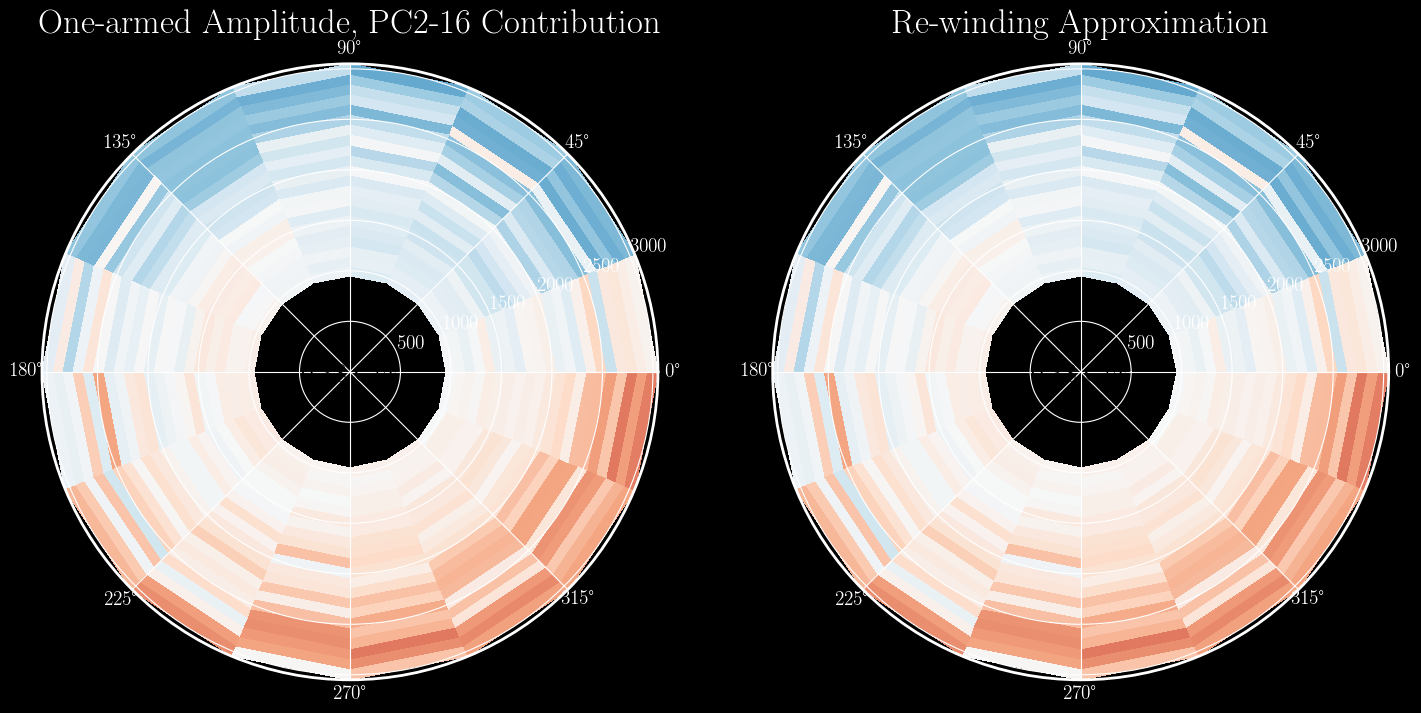

In [24]:
filename = fig_dir+'face-on_plots/pc2-16_rewinding_inttime0p4.mp4'
plt.style.use('dark_background')
shearing_box_movie(recon_amp, omega_phi, times, filename, jbins=20, rewind_time=0.38)

#### More Paper Plots

In [292]:
mssa.reconstruct(range(2,17))
get_recon = mssa.getReconstructed()
recon_amp_coefs = get_recon[list(get_recon.keys())[0]].getAllCoefs()
pc_rc = recon_amp_coefs

Updating for: (c)_0
Updating for: (s)_0
Updating for: (p)_0
Updating for: (N)_0
Updating for: (E)_0
Updating for: (o)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (Q)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (R)_0
Updating for: (B)_0
Updating for: (U)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (>)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (P)_0
Updating for: (E)_0
Updating for: (o)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


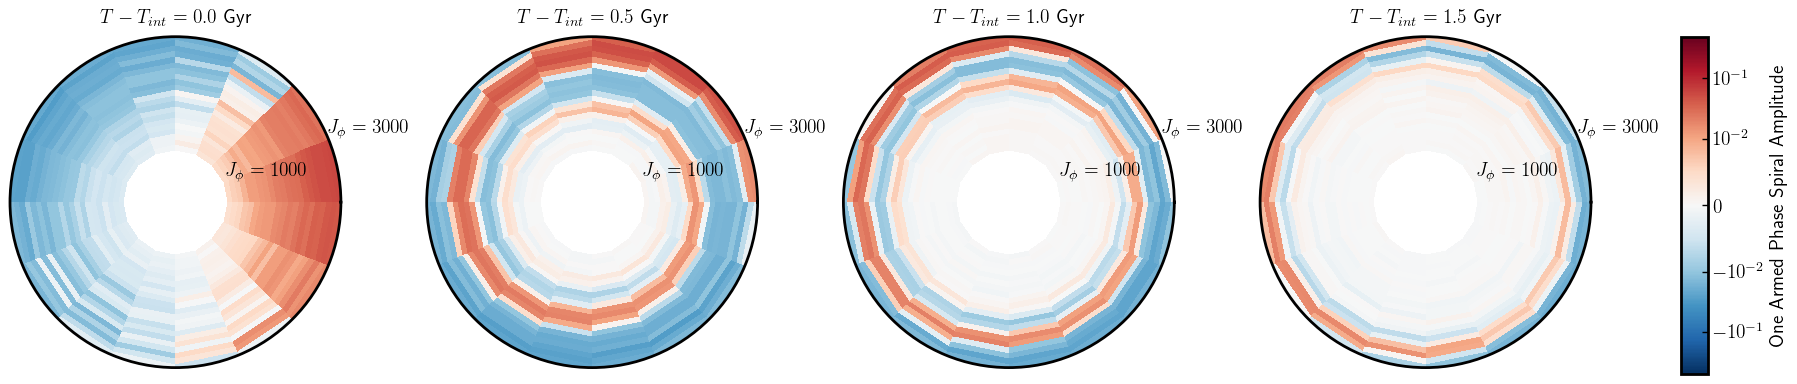

In [298]:
first_timestep = 2
fig, [ax1, ax2, ax3, ax4] = plt.subplots(1, 4, figsize=(18, 4.5), subplot_kw={'projection': 'polar'})

timestep=first_timestep+0
pc_rc_amp = pc_rc[:n_channels] 
pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)
amp_vmax=0.5

im1 = ax1.pcolormesh(T, J, np.reshape(pc_rc_amp[:,timestep], T.shape, 'F') - rad_mean_amp, 
                          cmap='RdBu_r', rasterized=True,
                          norm=mpl.colors.SymLogNorm(linthresh=amp_vmax/50, 
                                                     vmin=-amp_vmax, 
                                                     vmax=amp_vmax))
ax1.set_title(r'$T - T_{int} = 0.0$ Gyr', pad=10, fontsize=14)



timestep=first_timestep+50
pc_rc_amp = pc_rc[:n_channels] 
pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)
amp_vmax=0.5

im2 = ax2.pcolormesh(T, J, np.reshape(pc_rc_amp[:,timestep], T.shape, 'F') - rad_mean_amp, 
                          cmap='RdBu_r', rasterized=True,
                          norm=mpl.colors.SymLogNorm(linthresh=amp_vmax/50, 
                                                     vmin=-amp_vmax, 
                                                     vmax=amp_vmax))
ax2.set_title(r'$T - T_{int} = 0.5$ Gyr', pad=10, fontsize=14)



timestep=100
pc_rc_amp = pc_rc[:n_channels] 
pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)
amp_vmax=0.5

im3 = ax3.pcolormesh(T, J, np.reshape(pc_rc_amp[:,timestep], T.shape, 'F') - rad_mean_amp, 
                          cmap='RdBu_r', rasterized=True,
                          norm=mpl.colors.SymLogNorm(linthresh=amp_vmax/50, 
                                                     vmin=-amp_vmax, 
                                                     vmax=amp_vmax))
ax3.set_title(r'$T - T_{int} = 1.0$ Gyr', pad=10, fontsize=14)


timestep=150
pc_rc_amp = pc_rc[:n_channels] 
pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)
amp_vmax=0.5

im5 = ax4.pcolormesh(T, J, np.reshape(pc_rc_amp[:,timestep], T.shape, 'F') - rad_mean_amp, 
                          cmap='RdBu_r', rasterized=True,
                          norm=mpl.colors.SymLogNorm(linthresh=amp_vmax/50, 
                                                     vmin=-amp_vmax, 
                                                     vmax=amp_vmax))
ax4.set_title(r'$T - T_{int} = 1.5$ Gyr', pad=10, fontsize=14)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=3000$'])
    ax.set_rmax(np.max(jphi_c))
    ax.tick_params(left = False, right = False , labelleft = True ,
                         labelbottom = False, bottom = False)
    ax.grid(visible=False)

            

fig.tight_layout()


fig.subplots_adjust(right=0.89)
cbar_ax = fig.add_axes([0.94, 0.1, 0.015, 0.75])
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('One Armed Phase Spiral Amplitude')
plt.savefig(fig_dir + 'm1_amplitudes_paper.pdf')
plt.show()

/var/folders/f1/wqzqbly11d9__jf5mjckhwvm0000gq/T/ipykernel_39448/3410657830.py:55: UserWarning: Adding colorbar to a different Figure <Figure size 1800x450 with 5 Axes> than <Figure size 1500x500 with 4 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im3, cax=cbar_ax)



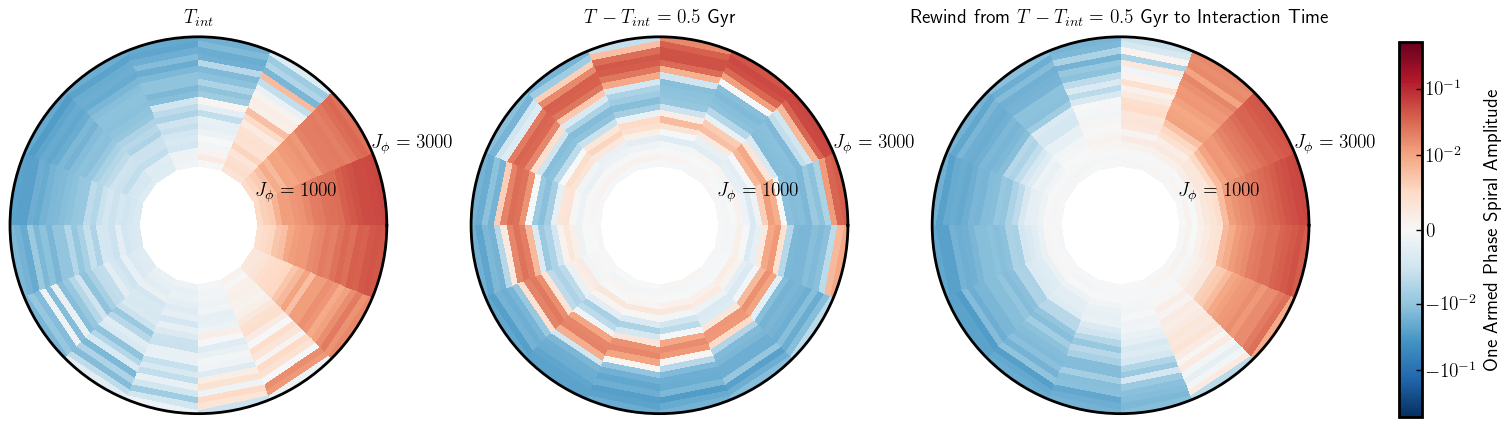

In [300]:
future_timestep = 50 #timesteps
dipole_timestep = 2
jbins=20

time_diff = times[1]-times[0]
ratio = 0.01

recon_amp_ = get_recon[list(get_recon.keys())[0]].getAllCoefs()
recon_amp = recon_amp_ - np.mean(recon_amp_, axis=0)

rad_mean_amp_dipole = np.mean(np.reshape(recon_amp[:,dipole_timestep], T.shape, 'F'), axis=0)
rad_mean_amp_future = np.mean(np.reshape(recon_amp[:,future_timestep], T.shape, 'F'), axis=0)

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'polar'})

im1 = ax1.pcolormesh(T, J, np.reshape(recon_amp[:,dipole_timestep], T.shape, 'F') - rad_mean_amp_dipole, 
                     cmap='RdBu_r', rasterized=True,
                     norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')


time_elapsed = (future_timestep - dipole_timestep) * ratio
d_rot = (time_elapsed * omega_phi)

#now interpolate at each radius so that I can use the same grid as before
interp = scipy.interpolate.interp1d(tphi_c, recon_amp[:,future_timestep].reshape((jbins+1, 16)), axis=1, 
                                    fill_value="extrapolate")
all_interp = interp((T+d_rot)%(2*np.pi))
future_grid = np.diagonal(all_interp, axis1=0, axis2=2)

#plot what that timestep looks like after subtracting background
im2 = ax3.pcolormesh(T, J, future_grid - rad_mean_amp_future, cmap='RdBu_r', rasterized=True,
                norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')

im2 = ax2.pcolormesh(T, J, np.reshape(recon_amp[:,future_timestep], T.shape, 'F') - rad_mean_amp_future, 
                     cmap='RdBu_r', rasterized=True,
                     norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')

ax1.set_title(r'$T_{int}$', pad=10, fontsize=14)
ax3.set_title(r'Rewind from $T - T_{int} = 0.5$ Gyr to Interaction Time', pad=10, fontsize=14)
ax2.set_title(r'$T - T_{int} = 0.5$ Gyr', pad=10, fontsize=14)


for ax in [ax1, ax2, ax3]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=3000$'])
    ax.set_rmax(np.max(jphi_c))
    ax.tick_params(left = False, right = False , labelleft = True ,
                         labelbottom = False, bottom = False)      
    ax.grid(visible=False)

fig.tight_layout()


fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.94, 0.1, 0.015, 0.75])
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('One Armed Phase Spiral Amplitude')
# plt.savefig(fig_dir + 'rewind_m1_amplitudes_paper.pdf')
plt.show()

### Time of Interaction from the Phase Spirals

$$\theta_z = \theta_{z,0} + \Omega_z \times t$$

In [31]:
from load_data import load_data
import astropy.units as u
import astropy.coordinates as coord

In [8]:
columns = ['R', 'phi', 'z', 'vR', 'vT', 'vz']
data10_ = Table.read('../data/Kiyan_10.fits')[columns]

In [32]:
ro=8*u.kpc
rep = coord.CylindricalRepresentation(
        rho=np.array(data10_['R']) * ro, 
        phi=(np.array(data10_['phi']) + np.pi) * u.rad,
        z=np.array(data10_['z']) * ro)

In [34]:
df = pd.DataFrame({'R': rep.rho.to_value(u.kpc)})

In [35]:
data10 = df.loc[np.isfinite(df.R) & (df.R != 0.)]

In [37]:
file1 = open('../data/Actions10.p', 'rb')
jr1,jphi1,jz1,O_R1,O_phi1,O_z1,theta_R1,theta_phi1,theta_z1=pickle.load(file1)

jz = jz1[data10.index]*8*220 # convert to kpc km/s
jphi = jphi1[data10.index]*8*220 # convert to kpc km/s
jr = jr1[data10.index]*8*220 # convert to kpc km/s

O_R = O_R1[data10.index]*27.5 # convert
O_phi = O_phi1[data10.index]*27.5 # convert
O_z = O_z1[data10.index]*27.5 # convert

theta_R = theta_R1[data10.index]
theta_phi = theta_phi1[data10.index]
theta_z = theta_z1[data10.index]

Strategy:
1. In each region of the disk, calculate $\Omega_z$ for $\sqrt{J_z} = 1$ and $\sqrt{J_z} = 3$ (exact numbers can change)
2. Given these $\Omega_z$ values, write a function which calculates the expected difference in $\theta_z$ at these two $\sqrt{J_z}$ values for any $t$
3. With the equation for the pitch angle, $\theta_z = \frac{1}{\tan(\psi)} \ln{\sqrt{J_z}} + \theta_{z,phase}$ , we can calculate the expected difference in $\theta_z$ in a given region of the disk.
4. Use this expected difference to solve for the time since the interaction

In [281]:
def pitch2deltatheta(pitch_angle, high_Rz, low_Rz):
    delta_theta = (np.log(high_Rz) - np.log(low_Rz)) / np.tan(pitch_angle)
    return delta_theta # this will be negative if the pitch angle is negative

def deltatheta2t(delta_theta, omegaz_high, omegaz_low):
    t = delta_theta / (omegaz_low - omegaz_high)
    return t

def get_omegaz(jphi_center, Rz_center):
    omegaz = np.median(O_z[(np.abs(jphi - jphi_center) < 50) & (np.abs(np.sqrt(jz) - Rz_center)< 0.1)])
    return omegaz

In [309]:
jphi_c = np.linspace(1000, 3000, 20+1)
all_ts_0p5Gyr = []
all_ts_1p0Gyr = []
for jphi_center in jphi_c:
    _, low_Rz  = scipy.stats.expon.fit(jz[(np.abs(jphi - jphi_center) < 50)], floc=0)
    print(jphi_center, low_Rz)
    high_Rz = low_Rz+2

    for i in range(16):
        index = int(16 * (jphi_center - 1000)/100 + i)
        
        omegaz_high = get_omegaz(jphi_center, low_Rz)
        omegaz_low = get_omegaz(jphi_center, high_Rz)
        pitch_0p5Gyr = coefs_m1_pitch0.getAllCoefs()[index,52]
        pitch_1p0Gyr = coefs_m1_pitch0.getAllCoefs()[index,102]
    
        dtheta_0p5Gyr = pitch2deltatheta(pitch_0p5Gyr, high_Rz, low_Rz)
        dtheta_1p0Gyr = pitch2deltatheta(pitch_1p0Gyr, high_Rz, low_Rz)
        
        t_0p5Gyr = deltatheta2t(dtheta_0p5Gyr, omegaz_high, omegaz_low)
        t_1p0Gyr = deltatheta2t(dtheta_1p0Gyr, omegaz_high, omegaz_low)
        all_ts_0p5Gyr = np.append(all_ts_0p5Gyr, t_0p5Gyr)
        all_ts_1p0Gyr = np.append(all_ts_1p0Gyr, t_1p0Gyr)

1000.0 4.534918993027143
1100.0 4.466785541133691
1200.0 4.3822445034064765
1300.0 4.280013922507431
1400.0 4.159230280518895
1500.0 4.023851135176248
1600.0 3.873525343500067
1700.0 3.721567027275862
1800.0 3.5647670210842404
1900.0 3.402172780665071
2000.0 3.2391538260571546
2100.0 3.0737486789224078
2200.0 2.91590318257817
2300.0 2.7574222448226897
2400.0 2.606283484506069
2500.0 2.440285695430602
2600.0 2.2890588745062344
2700.0 2.1203700423759817
2800.0 1.9571338497695405
2900.0 1.8163514187042327
3000.0 1.6664106665064577


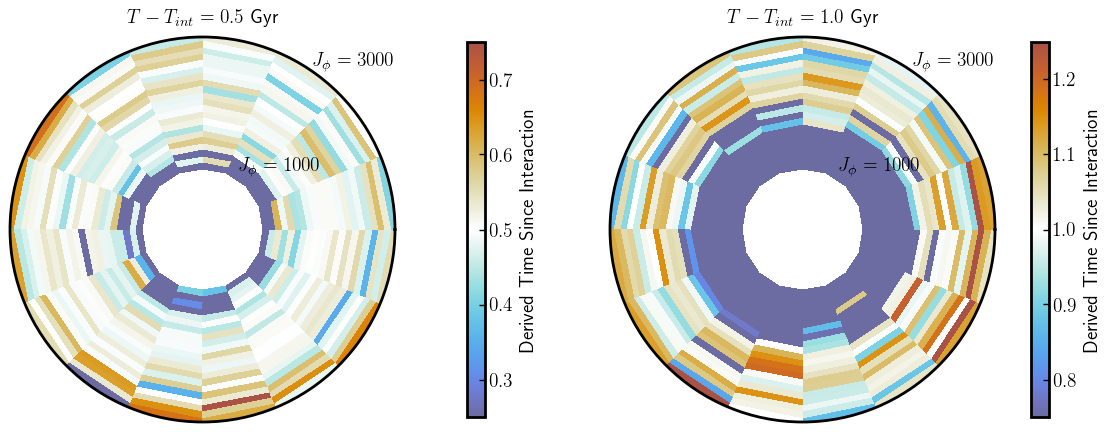

In [317]:
fig, [ax1, ax2] = plt.subplots(1,2, figsize=(12,5), subplot_kw={'projection': 'polar'}, gridspec_kw={'wspace':0.0, 'left':0, 'right':1})
im1 = ax1.pcolormesh(T, J, np.reshape(all_ts_0p5Gyr, T.shape, 'F'), 
                     cmap=cmr.prinsenvlag_r, rasterized=True, vmax=0.75, vmin=0.25, shading='nearest')
ax1.set_title(r'$T - T_{int} = 0.5$ Gyr', pad=10, fontsize=14)

im2 = ax2.pcolormesh(T, J, np.reshape(all_ts_1p0Gyr, T.shape, 'F'), 
                     cmap=cmr.prinsenvlag_r, rasterized=True, vmax=1.25, vmin=0.75, shading='nearest')
ax2.set_title(r'$T - T_{int} = 1.0$ Gyr', pad=10, fontsize=14)

for ax in [ax1, ax2]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=3000$'])
    ax.set_rmax(np.max(jphi_c))
    ax.set_rlabel_position(55)
    ax.tick_params(left = False, right = False , labelleft = True ,
                         labelbottom = False, bottom = False)      
    ax.grid(visible=False)
    
fig.subplots_adjust(right=0.85)
cbar_ax1 = fig.add_axes([0.47, 0.12, 0.015, 0.75])
cbar_ax2 = fig.add_axes([0.94, 0.12, 0.015, 0.75])
cbar1 = fig.colorbar(im1, cax=cbar_ax1)
cbar2 = fig.colorbar(im2, cax=cbar_ax2)
cbar1.set_label('Derived Time Since Interaction')
cbar2.set_label('Derived Time Since Interaction')

plt.show()